Saving archive.zip to archive (2).zip
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
    

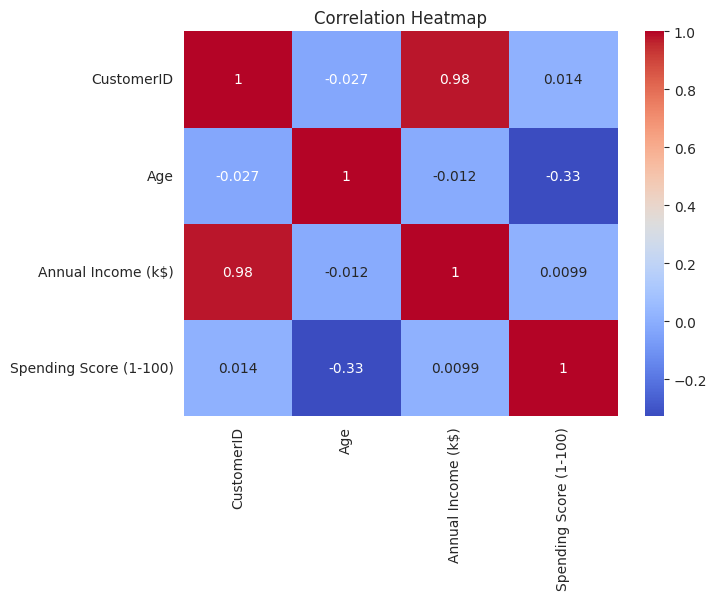

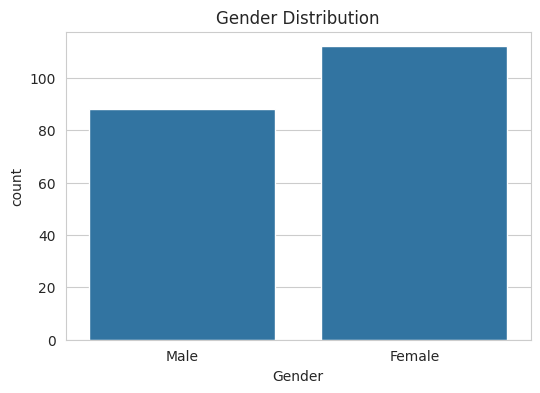

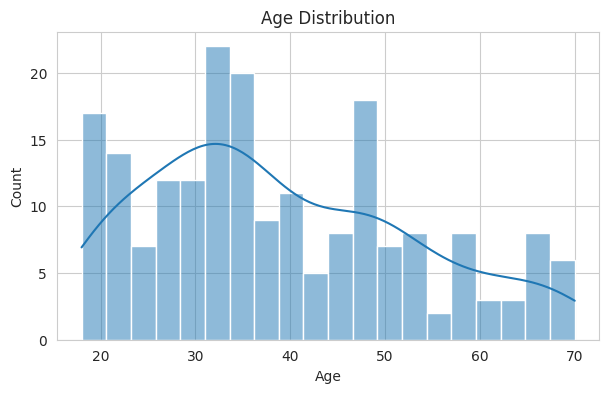

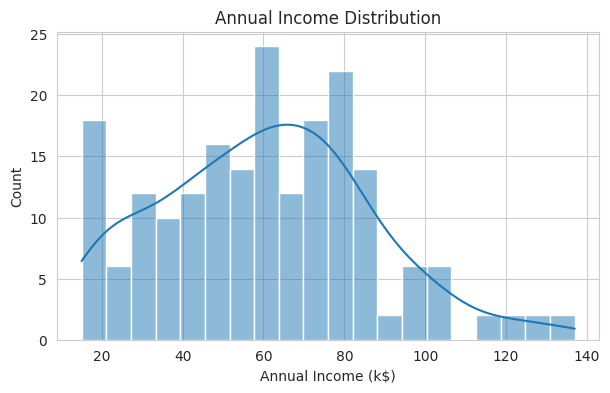

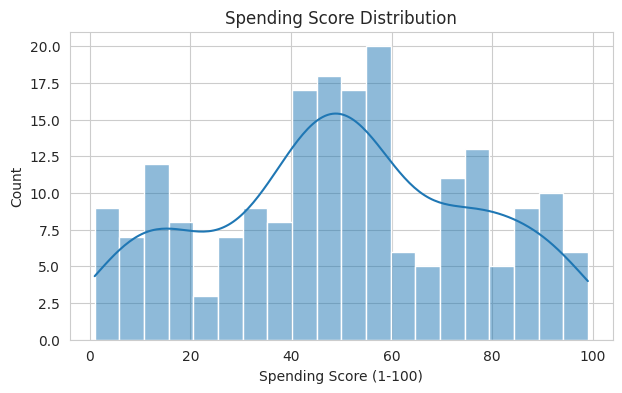

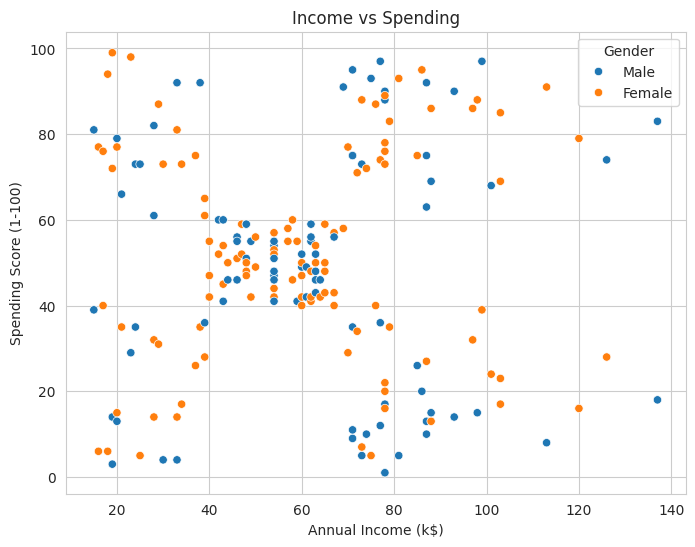

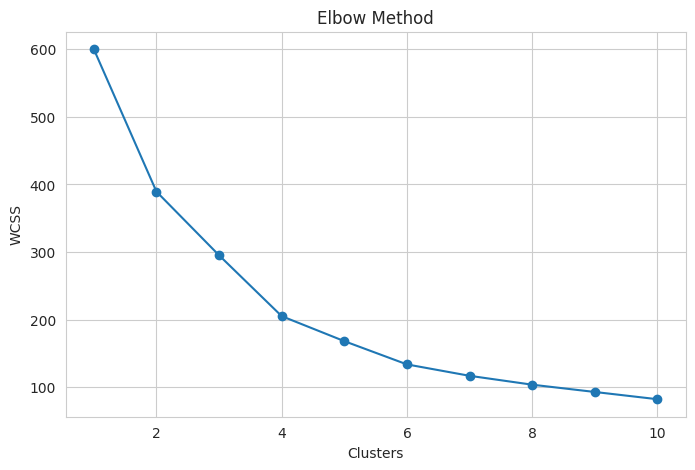

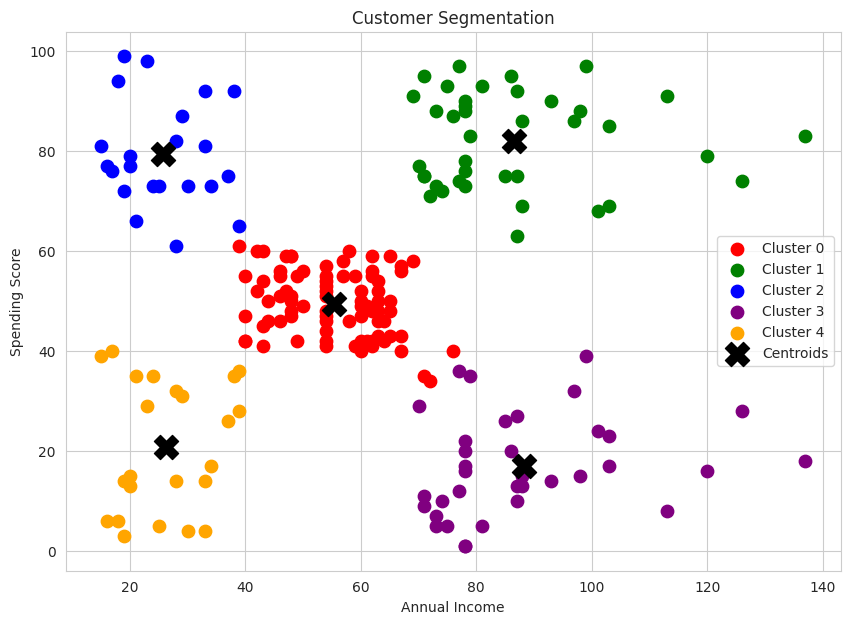

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064
Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64
Silhouette Score : 0.417


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Project Completed Successfully


In [3]:
!pip -q install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import files

sns.set_style("whitegrid")

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(7,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    data=df
)
plt.title("Income vs Spending")
plt.savefig("income_vs_spending.png")
plt.show()

X = df[["Age","Annual Income (k$)","Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig("elbow_method.png")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

plot_data = df[["Annual Income (k$)","Spending Score (1-100)"]]

plot_scaler = StandardScaler()
plot_scaled = plot_scaler.fit_transform(plot_data)

plot_model = KMeans(n_clusters=5, random_state=42, n_init=10)

plot_cluster = plot_model.fit_predict(plot_scaled)

centers = plot_scaler.inverse_transform(plot_model.cluster_centers_)

colors = ["red","green","blue","purple","orange"]

plt.figure(figsize=(10,7))

for i in range(5):
    plt.scatter(
        plot_data.iloc[plot_cluster==i,0],
        plot_data.iloc[plot_cluster==i,1],
        s=80,
        color=colors[i],
        label=f"Cluster {i}"
    )

plt.scatter(
    centers[:,0],
    centers[:,1],
    c="black",
    s=300,
    marker="X",
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.legend()
plt.grid(True)
plt.savefig("clusters.png")
plt.show()

summary = df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()

print(summary)

print(df["Cluster"].value_counts())

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score :", round(score,3))

df.to_csv("Clustered_Customers.csv", index=False)

files.download("Clustered_Customers.csv")

print("Project Completed Successfully")